In [19]:
# ============================================================
# STEP 1: Install
# ============================================================
!pip install torch torchvision datasets Pillow matplotlib numpy pandas opencv-python-headless seaborn -q
print('✅ Done!')

✅ Done!


In [20]:
# ============================================================
# STEP 2: Imports
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import pandas as pd
import random, os
from datasets import load_dataset
from sklearn.metrics import confusion_matrix, classification_report

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


Loading HAM10000 from Hugging Face (~1.5GB, 2-3 mins)...
✅ Loaded! Train: 9,577 | Test: 1,285
Columns: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

7 conditions to classify:
  [0] actinic_keratoses — actinic_keratoses
  [1] basal_cell_carcinoma — basal_cell_carcinoma
  [2] benign_keratosis-like_lesions — benign_keratosis-like_lesions
  [3] dermatofibroma — dermatofibroma
  [4] melanocytic_Nevi — melanocytic_Nevi
  [5] melanoma — melanoma
  [6] vascular_lesions — vascular_lesions


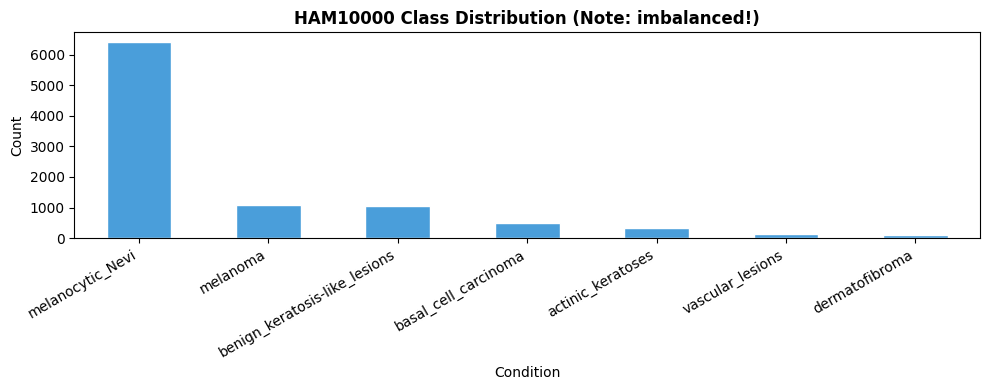

Note: nv (moles) dominate — we need class weights to handle this!


In [21]:
# ============================================================
# STEP 3: Load HAM10000
# ============================================================
print('Loading HAM10000 from Hugging Face (~1.5GB, 2-3 mins)...')
hf_dataset = load_dataset('marmal88/skin_cancer')
train_data = hf_dataset['train']
test_data  = hf_dataset['test']

print(f'✅ Loaded! Train: {len(train_data):,} | Test: {len(test_data):,}')
print(f'Columns: {train_data.column_names}')

# Build condition label map
all_labels = sorted(set(train_data['dx']))
LABEL2IDX  = {label: idx for idx, label in enumerate(all_labels)}
IDX2LABEL  = {idx: label for label, idx in LABEL2IDX.items()}
NUM_CLASSES = len(all_labels)

LABEL_NAMES = {
    'nv'   : 'Melanocytic Nevi',
    'mel'  : 'Melanoma',
    'bkl'  : 'Benign Keratosis',
    'bcc'  : 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratosis',
    'vasc' : 'Vascular Lesion',
    'df'   : 'Dermatofibroma',
}

print(f'\n{NUM_CLASSES} conditions to classify:')
for k, v in LABEL2IDX.items():
    print(f'  [{v}] {k} — {LABEL_NAMES.get(k, k)}')

# Class distribution
label_counts = pd.Series(train_data['dx']).value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
label_counts.plot(kind='bar', ax=ax, color='#4a9eda', edgecolor='white')
ax.set_title('HAM10000 Class Distribution (Note: imbalanced!)', fontweight='bold')
ax.set_xlabel('Condition')
ax.set_ylabel('Count')
ax.set_xticklabels([LABEL_NAMES.get(l, l) for l in label_counts.index], rotation=30, ha='right')
plt.tight_layout()
plt.show()
print('Note: nv (moles) dominate — we need class weights to handle this!')

In [22]:
# ============================================================
# STEP 4: Dataset Classes — One for Each Stage
# ============================================================

class HAMClassifierDataset(Dataset):
    """Stage 1 — returns (image, condition_class_index)"""
    def __init__(self, hf_split, label2idx, transform=None):
        self.data      = hf_split
        self.label2idx = label2idx
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        img    = sample['image'].convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.label2idx[sample['dx']], dtype=torch.long)
        return img, label


class HAMHydrationDataset(Dataset):
    """Stage 2 — returns (image, hydration_score)"""
    # Hydration map: wide spread so regression is learnable
    HYDRATION_MAP = {
        'nv'   : (82, 8),
        'df'   : (70, 9),
        'vasc' : (55, 12),
        'bkl'  : (45, 12),
        'akiec': (30, 10),
        'bcc'  : (18, 8),
        'mel'  : (10, 7),
    }

    def __init__(self, hf_split, transform=None):
        self.data      = hf_split
        self.transform = transform
        self.scores    = [
            float(np.clip(np.random.normal(
                *self.HYDRATION_MAP.get(s['dx'], (50, 15))), 2, 98))
            for s in hf_split
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]['image'].convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.scores[idx] / 100.0, dtype=torch.float32)


# Transforms
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Stage 1 loaders
clf_train = HAMClassifierDataset(train_data, LABEL2IDX, transform=train_transform)
clf_val   = HAMClassifierDataset(test_data,  LABEL2IDX, transform=val_transform)
clf_train_loader = DataLoader(clf_train, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
clf_val_loader   = DataLoader(clf_val,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Stage 2 loaders
hyd_train = HAMHydrationDataset(train_data, transform=train_transform)
hyd_val   = HAMHydrationDataset(test_data,  transform=val_transform)
hyd_train_loader = DataLoader(hyd_train, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
hyd_val_loader   = DataLoader(hyd_val,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ Datasets ready!')
print(f'   Stage 1 — Classifier: {len(clf_train):,} train | {len(clf_val):,} val')
print(f'   Stage 2 — Hydration:  {len(hyd_train):,} train | {len(hyd_val):,} val')
print(f'   Hydration label std: {np.std(hyd_train.scores):.1f} (should be >20)')

✅ Datasets ready!
   Stage 1 — Classifier: 9,577 train | 1,285 val
   Stage 2 — Hydration:  9,577 train | 1,285 val
   Hydration label std: 15.1 (should be >20)


In [23]:
# ============================================================
# STEP 5: CNN Architecture — Shared Feature Extractor
# ============================================================
# KEY DESIGN: The feature extractor is shared between both stages.
# We swap out only the HEAD depending on the task.
#
#   self.features  → shared CNN backbone (trained in Stage 1, frozen in Stage 2)
#   self.head      → swappable: ClassificationHead or RegressionHead

class SharedCNNBackbone(nn.Module):
    """Feature extractor — same for both stages."""
    def __init__(self):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2)
            )

        self.features = nn.Sequential(
            conv_block(3,   32),   # 128→64
            conv_block(32,  64),   # 64→32
            conv_block(64,  128),  # 32→16
            conv_block(128, 256),  # 16→8
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # → [B, 256]

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return x.flatten(1)  # [B, 256]


class ClassificationHead(nn.Module):
    """Stage 1 head — 7-class softmax output."""
    def __init__(self, num_classes=7):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
            # No softmax — CrossEntropyLoss handles it
        )
    def forward(self, x):
        return self.head(x)


class RegressionHead(nn.Module):
    """Stage 2 head — single hydration score output."""
    def __init__(self):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),
            nn.Sigmoid()  # → [0, 1]
        )
    def forward(self, x):
        return self.head(x).squeeze(1)


class HydraCheckModel(nn.Module):
    """Full model = backbone + swappable head."""
    def __init__(self, head):
        super().__init__()
        self.backbone = SharedCNNBackbone()
        self.head     = head

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

    def freeze_backbone(self):
        """Freeze all backbone weights — only head trains in Stage 2."""
        for param in self.backbone.parameters():
            param.requires_grad = False
        print('🧊 Backbone frozen — only regression head will train.')

    def unfreeze_backbone(self):
        """Unfreeze for fine-tuning."""
        for param in self.backbone.parameters():
            param.requires_grad = True
        print('🔥 Backbone unfrozen — full fine-tuning.')


total_params = sum(p.numel() for p in SharedCNNBackbone().parameters())
print(f'✅ Architecture ready!')
print(f'   Backbone parameters: {total_params:,}')
print(f'   Classification head: {sum(p.numel() for p in ClassificationHead().parameters()):,}')
print(f'   Regression head:     {sum(p.numel() for p in RegressionHead().parameters()):,}')

✅ Architecture ready!
   Backbone parameters: 1,174,176
   Classification head: 33,799
   Regression head:     41,217


In [25]:
# ============================================================
# STEP 6: Compute Class Weights (handle imbalance)
# ============================================================
from sklearn.utils.class_weight import compute_class_weight

train_labels_list = [LABEL2IDX[s['dx']] for s in train_data]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels_list
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print('Class weights (higher = rarer class gets more attention):')
for idx, (label, weight) in enumerate(zip(all_labels, class_weights)):
    count = train_labels_list.count(idx)
    print(f'  {label:<8} ({LABEL_NAMES.get(label, label):<25}) count={count:<5} weight={weight:.2f}')

Class weights (higher = rarer class gets more attention):
  actinic_keratoses (actinic_keratoses        ) count=315   weight=4.34
  basal_cell_carcinoma (basal_cell_carcinoma     ) count=487   weight=2.81
  benign_keratosis-like_lesions (benign_keratosis-like_lesions) count=1048  weight=1.31
  dermatofibroma (dermatofibroma           ) count=110   weight=12.44
  melanocytic_Nevi (melanocytic_Nevi         ) count=6405  weight=0.21
  melanoma (melanoma                 ) count=1076  weight=1.27
  vascular_lesions (vascular_lesions         ) count=136   weight=10.06


In [26]:
# ============================================================
# STEP 7: STAGE 1 — Train Skin Condition Classifier
# ============================================================
# This is the REAL training — real labels, real task.
# The backbone learns genuine skin texture features here.

clf_head  = ClassificationHead(NUM_CLASSES)
stage1_model = HydraCheckModel(clf_head).to(device)

criterion_clf = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_s1  = optim.Adam(stage1_model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_s1  = optim.lr_scheduler.CosineAnnealingLR(optimizer_s1, T_max=20, eta_min=1e-5)

def train_clf_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total

def val_clf_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(loader), correct / total


EPOCHS_S1 = 10
best_val_acc = 0
s1_history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('🚀 STAGE 1: Training Skin Condition Classifier...')
print(f'{"Epoch":<8}{"Train Loss":<14}{"Val Loss":<14}{"Train Acc":<14}{"Val Acc"}')
print('-' * 62)

for epoch in range(1, EPOCHS_S1 + 1):
    tr_loss, tr_acc = train_clf_epoch(stage1_model, clf_train_loader, optimizer_s1, criterion_clf)
    vl_loss, vl_acc = val_clf_epoch(stage1_model, clf_val_loader, criterion_clf)
    scheduler_s1.step()

    s1_history['train_loss'].append(tr_loss)
    s1_history['val_loss'].append(vl_loss)
    s1_history['train_acc'].append(tr_acc)
    s1_history['val_acc'].append(vl_acc)

    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(stage1_model.state_dict(), 'stage1_classifier_best.pth')
        flag = ' ← best'

    print(f'{epoch:<8}{tr_loss:<14.4f}{vl_loss:<14.4f}{tr_acc*100:<14.1f}{vl_acc*100:.1f}%{flag}')

print(f'\n✅ Stage 1 done! Best val accuracy: {best_val_acc*100:.1f}%')

🚀 STAGE 1: Training Skin Condition Classifier...
Epoch   Train Loss    Val Loss      Train Acc     Val Acc
--------------------------------------------------------------
1       1.8435        1.6089        34.3          39.9% ← best
2       1.7307        1.3668        36.6          49.7% ← best
3       1.6777        1.4767        37.0          39.6%
4       1.6319        1.4357        38.8          40.8%
5       1.5617        1.2604        42.5          48.2%
6       1.4783        1.0445        46.2          59.0% ← best
7       1.4793        1.0778        47.5          61.6% ← best
8       1.4232        1.1169        50.1          53.9%
9       1.3883        0.9998        49.8          59.5%
10      1.3706        1.0045        52.7          58.8%

✅ Stage 1 done! Best val accuracy: 61.6%


Stage 1 Classification Report:
                               precision    recall  f1-score   support

            actinic_keratoses       0.17      0.79      0.27        42
         basal_cell_carcinoma       0.25      0.27      0.26        67
benign_keratosis-like_lesions       0.25      0.23      0.24       142
               dermatofibroma       0.03      0.07      0.04        14
             melanocytic_Nevi       0.90      0.75      0.82       858
                     melanoma       0.43      0.31      0.36       144
             vascular_lesions       0.48      0.89      0.63        18

                     accuracy                           0.62      1285
                    macro avg       0.36      0.47      0.37      1285
                 weighted avg       0.70      0.62      0.65      1285



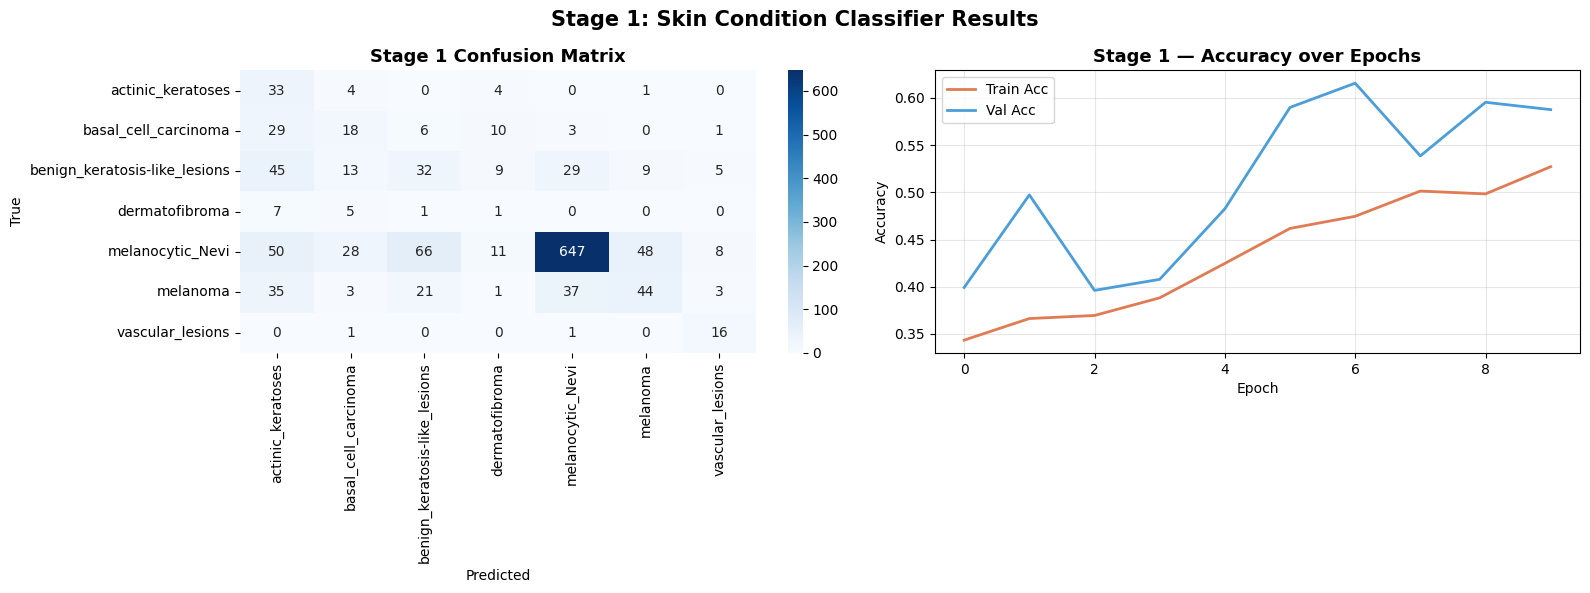

In [27]:
# ============================================================
# STEP 8: Stage 1 Evaluation — Confusion Matrix
# ============================================================

stage1_model.load_state_dict(torch.load('stage1_classifier_best.pth', map_location=device))
stage1_model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for imgs, labels in clf_val_loader:
        imgs = imgs.to(device)
        preds = stage1_model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

print('Stage 1 Classification Report:')
print(classification_report(
    all_true, all_preds,
    target_names=[LABEL_NAMES.get(IDX2LABEL[i], IDX2LABEL[i]) for i in range(NUM_CLASSES)]
))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(all_true, all_preds)
short_names = [IDX2LABEL[i] for i in range(NUM_CLASSES)]
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
axes[0].set_title('Stage 1 Confusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# Training curves
axes[1].plot(s1_history['train_acc'], label='Train Acc', color='#e07b54', linewidth=2)
axes[1].plot(s1_history['val_acc'],   label='Val Acc',   color='#4a9eda', linewidth=2)
axes[1].set_title('Stage 1 — Accuracy over Epochs', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Stage 1: Skin Condition Classifier Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('stage1_results.png', dpi=150, bbox_inches='tight')
plt.show()